<a href="https://colab.research.google.com/github/PrithuVerma/Health-Insurance-Claim-Analysis/blob/main/Health_Insurance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Health Insurance Analysis
**Task :** To perform EDA on the given datasets and extract necessary information out out it as well as make visuals for meaningful insights.

*The following file is part of [Github Repo Link](https://github.com/PrithuVerma/Health-Insurance-Claim-Analysis)*

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Creation Process

* The following datasets were created using [Faker](https://faker.readthedocs.io/en/master/) library of python  

* All the data was saved in parquet file format beacuse of large size of data and ease of data compression and handling.

* Data was extracted using [ETL Pipeline](https://github.com/PrithuVerma/Health-Insurance-Claim-Analysis/tree/main/ETL%20Pipeline) ,to edit the fields or increase the data edit the config.py file




In [4]:
patients = pd.read_parquet('/content/drive/MyDrive/Health_Insurance_Project/processed/patients.parquet')
policies = pd.read_parquet('/content/drive/MyDrive/Health_Insurance_Project/processed/policies.parquet')
procedures = pd.read_parquet('/content/drive/MyDrive/Health_Insurance_Project/processed/procedures.parquet')
hospitals = pd.read_parquet('/content/drive/MyDrive/Health_Insurance_Project/processed/hospitals.parquet')
claim_rev = pd.read_parquet('/content/drive/MyDrive/Health_Insurance_Project/processed/claim_reviews.parquet')
claims = pd.read_parquet('/content/drive/MyDrive/Health_Insurance_Project/processed/claims.parquet')

In [5]:
patients.head()

,patient_id,first_name,last_name,dob,gender,phone_num,address,email
0,PAT0000001,Divyansh,Char,1947-08-01,Other,6415955403,H.No. 11\nRandhawa Ganj\nSilchar-362177,lkanda@gmail.com
1,PAT0000002,Renee,Dave,1997-10-31,Female,6877090314,"H.No. 08, Sant\nBallia 613500",omane@yahoo.com
2,PAT0000003,Vanya,Vyas,1993-05-26,Other,8690521513,95\nGopal Chowk\nAjmer-111404,abarad@hotmail.com
3,PAT0000004,Jayesh,Trivedi,1983-11-12,Male,9532401492,"66, Goda Path\nBhalswa Jahangir Pur 588268",banikzeeshan@hotmail.com
4,PAT0000005,Madhav,Sura,1948-01-07,Male,6509387052,"H.No. 15, Deo Road, Orai-097623",lagan81@hotmail.com


In [6]:
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   patient_id  750000 non-null  object        
 1   first_name  750000 non-null  object        
 2   last_name   750000 non-null  object        
 3   dob         750000 non-null  datetime64[ns]
 4   gender      750000 non-null  object        
 5   phone_num   750000 non-null  object        
 6   address     750000 non-null  object        
 7   email       750000 non-null  object        
dtypes: datetime64[ns](1), object(7)
memory usage: 45.8+ MB


## 1. Age distribution of Patients

In [7]:
from datetime import datetime,date
patients['dob'] = pd.to_datetime(patients['dob'])
patients['age'] = ((datetime.today() - patients['dob']).dt.days) // 365

In [8]:
patients['age'].head()

,age
0,78
1,28
2,32
3,42
4,78


In [9]:
patients.drop(columns='email', inplace = True)

In [10]:
patients.columns

Index(['patient_id', 'first_name', 'last_name', 'dob', 'gender', 'phone_num',
       'address', 'age'],
      dtype='object')

In [11]:
max_age = patients.age.max()
min_age = patients.age.min()
median_age = patients.age.median()

In [12]:
print(max_age)
print(min_age)
print(median_age)

81
19
50.0


In [13]:
patients['age_bin'] = pd.cut(
    patients['age'],
    bins=[18, 30, 45, 60, 81],
    labels=['Young Adult', 'Adult', 'Middle-aged', 'Senior']
)


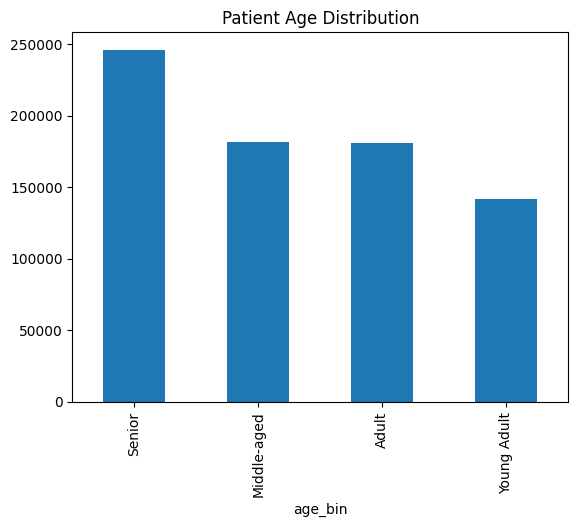

In [14]:
patients['age_bin'].value_counts().plot(kind='bar')
plt.title('Patient Age Distribution')
plt.show()

## 2. Claim Amount Distribution

In [15]:
claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65486 entries, 0 to 65485
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   claim_id         65486 non-null  object        
 1   policy_id        65486 non-null  object        
 2   hospital_id      65486 non-null  object        
 3   claim_date       65486 non-null  datetime64[ns]
 4   total_amount     65486 non-null  float64       
 5   approved_amount  65486 non-null  float64       
 6   status           65486 non-null  object        
dtypes: datetime64[ns](1), float64(2), object(4)
memory usage: 3.5+ MB


In [16]:
claims.describe()

,claim_date,total_amount,approved_amount
count,65486,65486.000000,65486.000000
mean,2021-01-26 04:02:27.329200128,49836.460541,33338.686234
min,2018-01-01 00:00:00,0.290000,0.250000
25%,2019-07-07 00:00:00,14323.625000,10365.060000
50%,2021-01-13 00:00:00,34617.645000,23957.925000
75%,2022-07-20 00:00:00,69009.830000,45750.842500
max,2024-12-30 00:00:00,600659.960000,447856.470000
std,NaN,49695.777450,32858.167552


In [17]:
claims.columns

Index(['claim_id', 'policy_id', 'hospital_id', 'claim_date', 'total_amount',
       'approved_amount', 'status'],
      dtype='object')

In [18]:
claims['total_amount'].describe()

,total_amount
count,65486.000000
mean,49836.460541
std,49695.777450
min,0.290000
25%,14323.625000
50%,34617.645000
75%,69009.830000
max,600659.960000


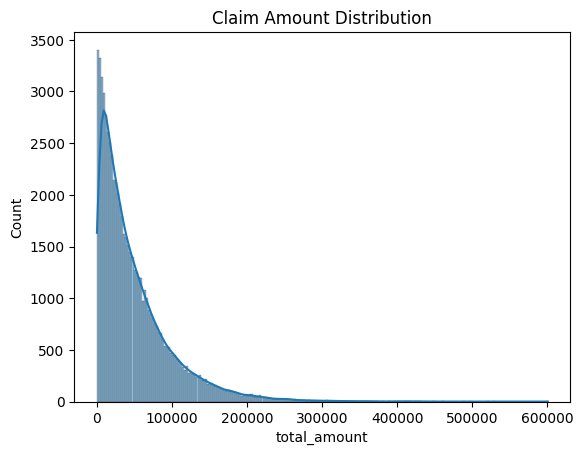

In [19]:
sns.histplot(data=claims['total_amount'], kde=True)
plt.title('Claim Amount Distribution')
plt.show()

In [20]:
procedures.head()

,procedure_id,claim_id,procedure_name,category,cost,procedure_date
0,PRC0000001,CLM0000001,Chemotherapy,Therapy,31398.18,2020-07-31
1,PRC0000022,CLM0000011,Bypass Surgery,Surgery,37023.46,2024-11-09
2,PRC0000023,CLM0000011,Bypass Surgery,Surgery,147272.85,2024-11-09
3,PRC0000024,CLM0000012,Dialysis,Therapy,99454.30,2020-06-28
4,PRC0000026,CLM0000014,MRI Scan,Diagnostic,132857.53,2023-07-03


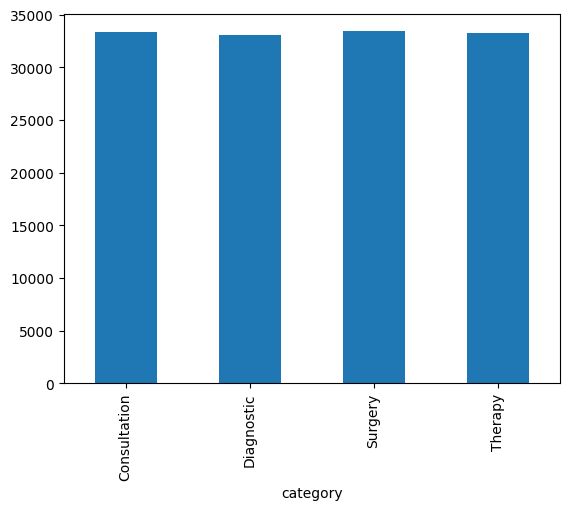

In [21]:
claims_n_pro = claims.merge(procedures,how = 'left',on='claim_id')
avg_claims_by_pro = claims_n_pro.groupby('category')['approved_amount'].mean().round(2).plot(kind = 'bar')

<Axes: ylabel='procedure_name,category'>

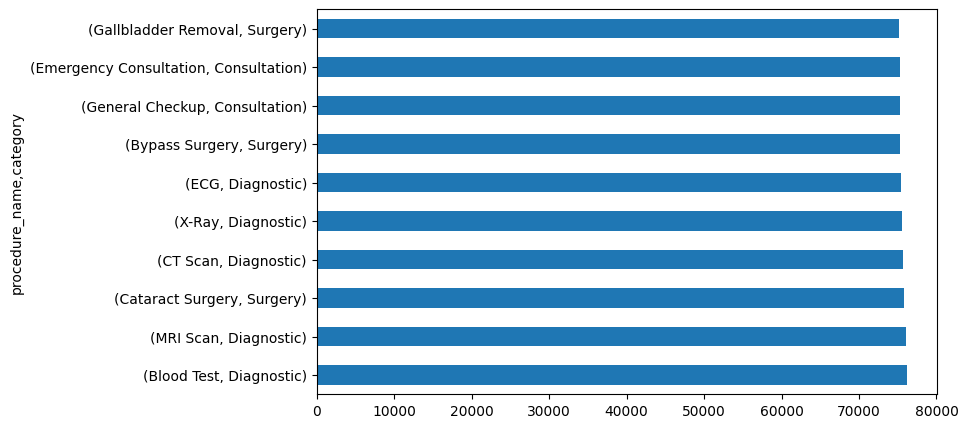

In [22]:
pro_max_cost = procedures.groupby(['procedure_name','category'])['cost'].mean().round(2)
pro_max_cost.sort_values(ascending = False).head(10).plot(kind = 'barh',figsize=(8,5))

## 4. Approval Rate by Gender

In [23]:
claim_status = claims_n_pro['status'].value_counts()

In [24]:
claims_n_pro['gender'] = patients['gender']

<Axes: xlabel='gender'>

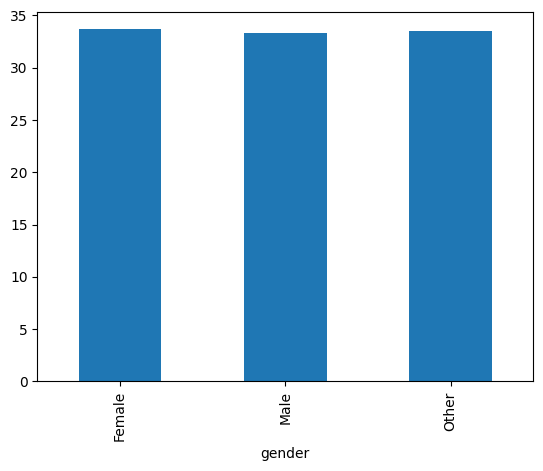

In [25]:
approved = claims_n_pro[claims_n_pro['status']=='Approved'].groupby('gender').size()
total = claims_n_pro.groupby('gender').size()

approval_rate = approved / total * 100
approval_rate.plot(kind='bar')

## 5. States whith the highest total claims filed

In [26]:
claims_n_hos = hospitals.merge(claims,how='left',on='hospital_id')
claims_n_hos.head()

,hospital_id,name,city,state,type,phone_num,email,claim_id,policy_id,claim_date,total_amount,approved_amount,status
0,HSP0001,Gour LLC Hospital,Tinsukia,Chhattisgarh,Clinic,9066726676,riaan84@saran.info,CLM0002231,POL0275213,2023-09-09,6421.31,5279.06,Approved
1,HSP0001,Gour LLC Hospital,Tinsukia,Chhattisgarh,Clinic,9066726676,riaan84@saran.info,CLM0002450,POL0233430,2019-05-16,31323.81,23213.12,Approved
2,HSP0001,Gour LLC Hospital,Tinsukia,Chhattisgarh,Clinic,9066726676,riaan84@saran.info,CLM0003672,POL0296652,2018-02-14,6915.72,3542.77,Approved
3,HSP0001,Gour LLC Hospital,Tinsukia,Chhattisgarh,Clinic,9066726676,riaan84@saran.info,CLM0004156,POL0170422,2022-11-04,17863.38,12031.62,Denied
4,HSP0001,Gour LLC Hospital,Tinsukia,Chhattisgarh,Clinic,9066726676,riaan84@saran.info,CLM0004732,POL0209470,2021-01-10,6510.31,3556.14,Pending


In [27]:
claims_n_hos['claim_id'].count()

np.int64(65486)

<Axes: xlabel='state'>

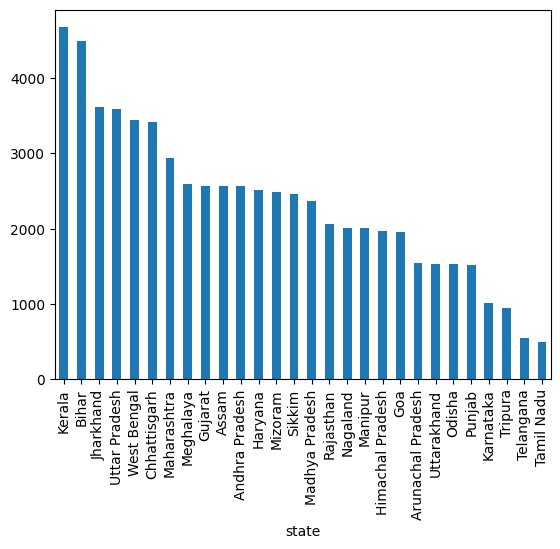

In [28]:
state_wise_claims = claims_n_hos.groupby('state')['claim_id'].count().sort_values(ascending=False).plot(kind = 'bar')
state_wise_claims

## 6. Average Processing time by decision type

In [29]:
claim_n_rev = claim_rev.merge(claims,how = 'left', on = 'claim_id')
claim_n_rev.head()

,review_id,claim_id,review_date,decision,reviewer_name,rejection_reason,policy_id,hospital_id,claim_date,total_amount,approved_amount,status
0,REV0000003,CLM0175539,2023-08-25,Approved,Inaaya Mane,None,POL0262334,HSP0118,2023-08-24,15407.61,8518.91,Pending
1,REV0000004,CLM0295844,2024-02-25,Approved,Vanya Raju,None,POL0009693,HSP0003,2024-02-24,11418.67,11306.97,Denied
2,REV0000007,CLM0046619,2018-10-10,Denied,Emir Bhasin,Duplicate claim,POL0242007,HSP0109,2018-10-09,211881.65,93771.03,Pending
3,REV0000009,CLM0271950,2024-06-27,Approved,Ehsaan Sinha,None,POL0270103,HSP0072,2024-01-06,18155.29,14469.94,Approved
4,REV0000017,CLM0217392,2023-01-30,Approved,Aniruddh Wali,None,POL0092532,HSP0005,2023-01-29,2571.40,1546.21,Approved


In [30]:
avg_processing_time_days = (
    (claim_n_rev['review_date'] - claim_n_rev['claim_date']).mean().days
)
avg_processing_time_days

500

## 7. Monthly claim trend over the years

Text(0.5, 0, '')

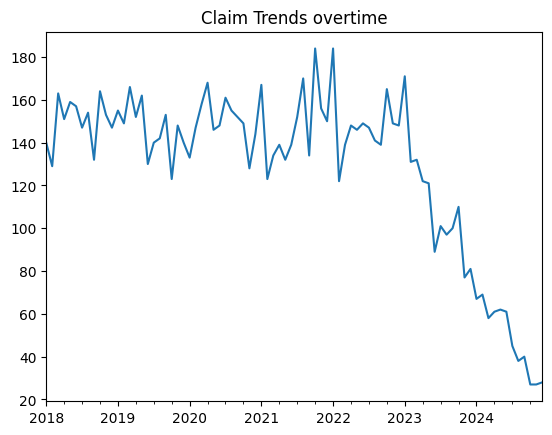

In [34]:
claim_n_rev['month'] = claim_n_rev['claim_date'].dt.to_period('M')

claim_n_rev.groupby('month')['claim_id'].count().plot(kind='line')
plt.title('Claim Trends overtime')
plt.xlabel(None)